In [3]:
import os, sys
import os, sys
sys.path.insert(0, r'C:\Users\sp6497_a\FTIR')
import matplotlib.pyplot as plt
import numpy as np
from FTIR_analysis_helpers import MultipassMeas
from FTIR_analysis_helpers import load_data
from FTIR_analysis_helpers import build_MP
from matplotlib.ticker import MaxNLocator
from FTIR_analysis_helpers import fitLorentzPlot

In [4]:
sample_name = 'P12-9-25-1MP'
ap_bg = 15
gain_bg = 2
att_bg = 'mod'
preamp = 'PA101'

# settings_suffix_bg = 'ap_' + str(ap_bg) + '_gain_' + str(gain_bg)
settings_suffix_bg = 'att_' + att_bg

settings_suffix_samp = preamp + '-preamp-matched'

numax = 3100
numin = 820

base_dir = r'C:\Users\sp6497_a\OneDrive - Princeton University\20260203_P12-9-25-1-MP\20260211'
bg_dir = base_dir

In [5]:
tm_file = os.path.join(base_dir, sample_name+ '-P0deg' + '.CSV')
te_file = os.path.join(base_dir, sample_name+ '-P90deg' + '.CSV')

samp_meas = build_MP(te_file,tm_file,sample_name,nuextrema=[numin,numax])

tm_bg_file = os.path.join(bg_dir,'P0deg_' + 'bg_realigned' + '.CSV')
te_bg_file = os.path.join(bg_dir, 'P90deg_' + 'bg_realigned' + '.CSV')

bg_meas = build_MP(te_bg_file,tm_bg_file,'no_samp',nuextrema=[numin,numax])


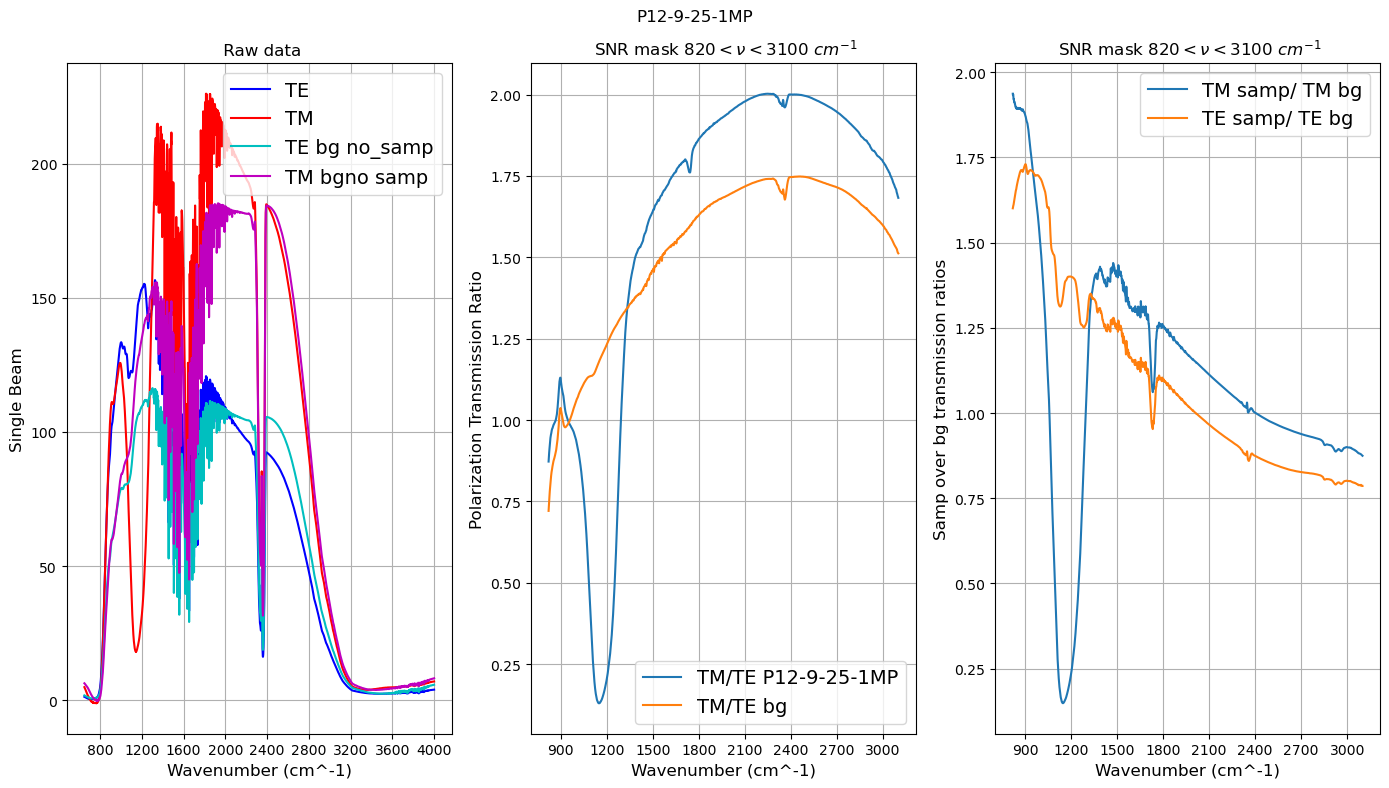

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(14, 8))

overall_title =sample_name
fig.suptitle(overall_title)

axs[0].set_xlabel('Wavenumber (cm^-1)',fontsize=12)
axs[0].set_ylabel("Single Beam",fontsize=12)
theta_variation_title =' Raw data'
axs[0].set_title(theta_variation_title)

fit_plot_title = " SNR mask " + str(numin) + r"$ < \nu < $" + str(numax) + r" ${cm}^{-1}$"
axs[1].set_title(fit_plot_title)
axs[1].set_xlabel('Wavenumber (cm^-1)',fontsize=12)
axs[1].set_ylabel('Polarization Transmission Ratio',fontsize=12)

fit_plot_title = " SNR mask " + str(numin) + r"$ < \nu < $" + str(numax) + r" ${cm}^{-1}$"
axs[2].set_title(fit_plot_title)
axs[2].set_xlabel('Wavenumber (cm^-1)',fontsize=12)
axs[2].set_ylabel('Samp over bg transmission ratios',fontsize=12)

axs[0].grid()
axs[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[1].grid()
axs[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[2].grid()
axs[2].xaxis.set_major_locator(MaxNLocator(integer=True))

axs[0].plot(samp_meas.TE_wavenum, samp_meas.TE_single_beam, label= 'TE',
                        color='blue')
axs[0].plot(samp_meas.TM_wavenum , samp_meas.TM_single_beam , label= 'TM',
                        color='red')

axs[0].plot(bg_meas.TE_wavenum, bg_meas.TE_single_beam, label= 'TE bg ' + 'no_samp',
                        color='c')
axs[0].plot(bg_meas.TM_wavenum , bg_meas.TM_single_beam , label='TM bg' + 'no samp',
                        color='m')


axs[1].plot(samp_meas.TM_wavenum_masked, samp_meas.TM_masked / samp_meas.TE_masked,
            label='TM/TE ' + sample_name)
axs[1].plot(bg_meas.TM_wavenum_masked, bg_meas.TM_masked / bg_meas.TE_masked,
            label='TM/TE ' + 'bg')

axs[2].plot(samp_meas.TM_wavenum_masked, samp_meas.TM_masked / bg_meas.TM_masked,
            label='TM samp/ TM bg')
axs[2].plot(samp_meas.TE_wavenum_masked, samp_meas.TE_masked / bg_meas.TE_masked,
            label='TE samp/ TE bg')

plt.figure(fig)
axs[0].legend()
axs[0].legend(prop={"size":14})
axs[1].legend()
axs[1].legend(prop={"size":14})
axs[2].legend()
axs[2].legend(prop={"size":14})
plt.tight_layout()
save_title = os.path.join(base_dir, sample_name + 'raw scans and ratios' + '.svg')
plt.savefig(save_title)

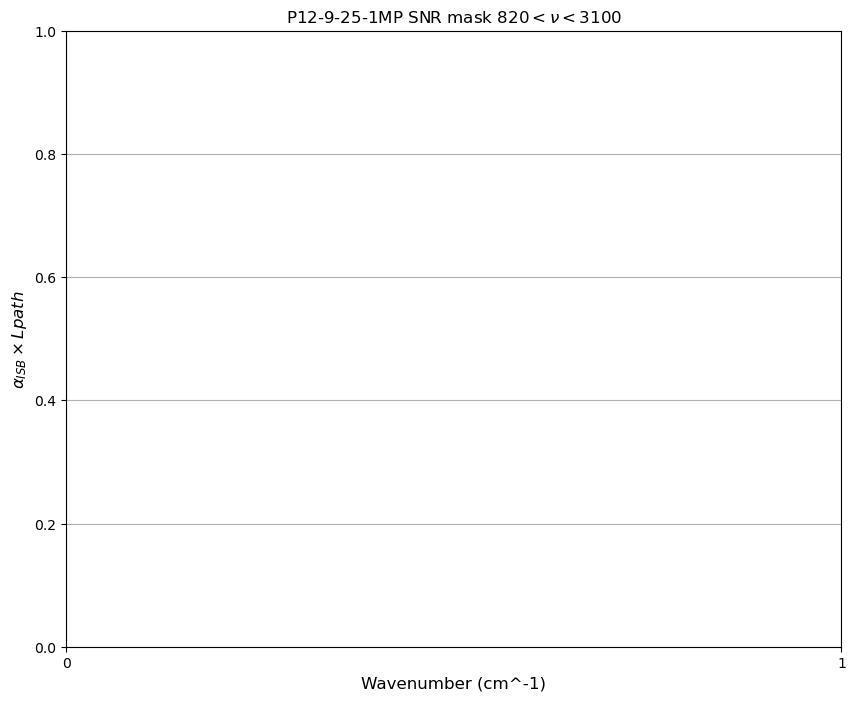

In [7]:
fig_fits, axs_fits = plt.subplots(figsize=(10, 8))
axs_fits.set_xlabel('Wavenumber (cm^-1)',fontsize=12)
axs_fits.set_ylabel(r"$\alpha_{ISB} \times L{path} $",fontsize=12)
fit_plot_title = sample_name + " SNR mask " + str(numin) + r"$ < \nu < $" + str(numax)
axs_fits.set_title(fit_plot_title)
axs_fits.grid()
axs_fits.xaxis.set_major_locator(MaxNLocator(integer=True))

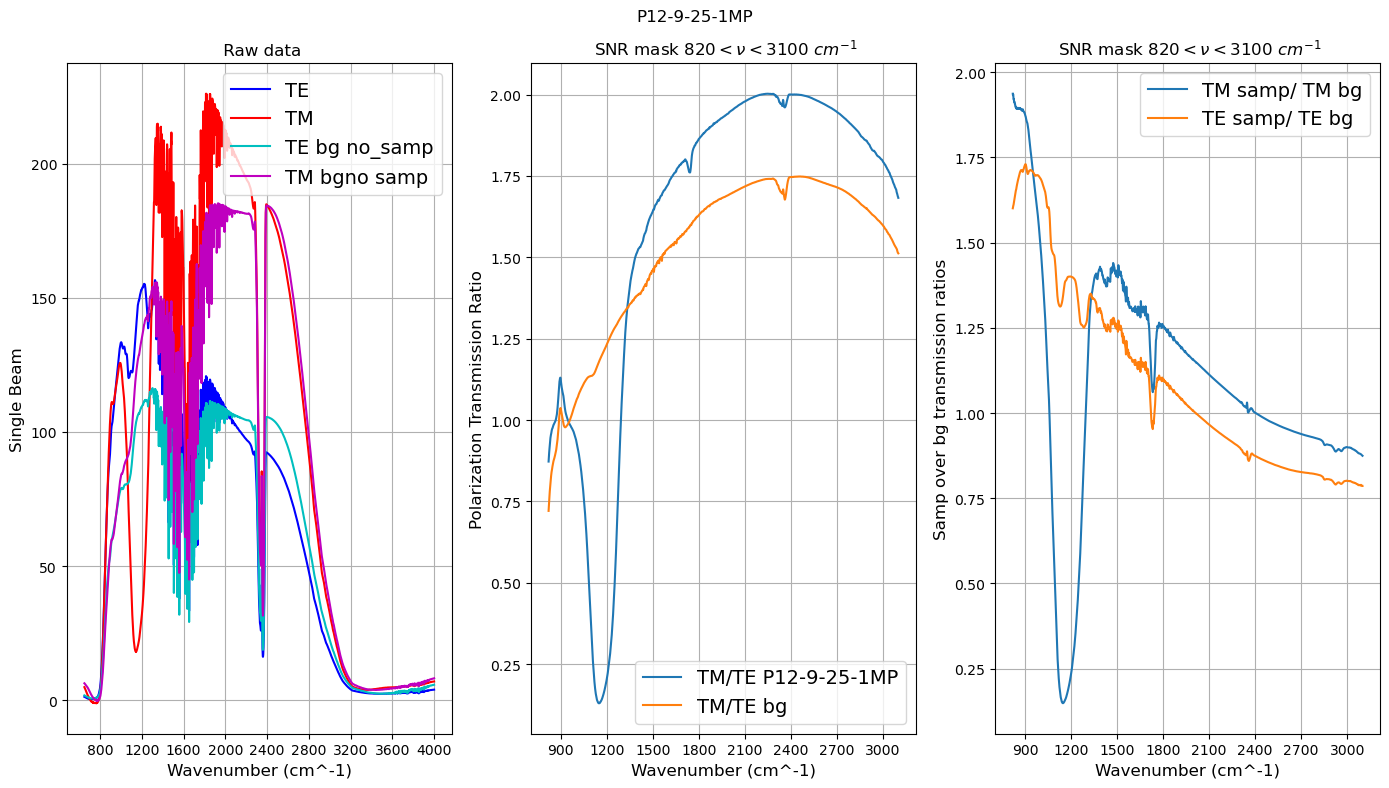

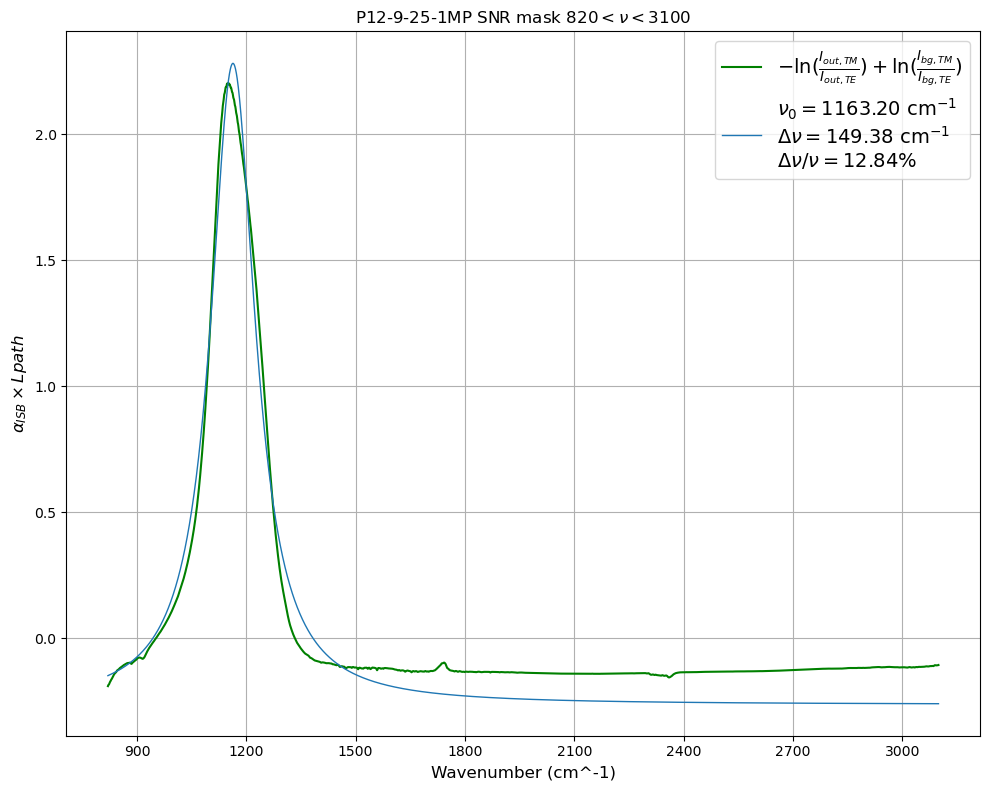

In [8]:
offset = np.log(bg_meas.TM_masked/bg_meas.TE_masked)

alpha_ISB= -np.log(samp_meas.TM_masked/samp_meas.TE_masked)+offset
axs_fits.plot(samp_meas.TM_wavenum_masked, alpha_ISB, color='green',label = r"$-\ln (\frac{I_{out,TM}}{I_{out,TE}}) + \ln(\frac{I_{bg,TM}}{I_{bg,TE}}) $")

numins = [1060]
numaxs = [1670]
kappa_nu_guesses = [65]
for i in range(0,len(numins)):
    nu_range = [numins[i],numaxs[i]]
    kappa_nu_guess = kappa_nu_guesses[i]
    fitLorentzParams = fitLorentzPlot(nu_range, kappa_nu_guess,samp_meas.TE_wavenum_masked, alpha_ISB, axs_fits)

plt.figure(fig_fits)
axs_fits.legend()
axs_fits.legend(prop={"size":14})

plt.tight_layout()
save_title = os.path.join(base_dir, sample_name + 'alpha_ISB' + '.svg')
plt.savefig(save_title)

plt.figure(fig)
plt.show()
plt.figure(fig_fits)
plt.show()